In [1]:
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()

DATA_PATH = PROJECT_ROOT / "data" / "origin_data.xlsx"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TAB_DIR = RESULTS_DIR / "tables"
RUN_DIR = RESULTS_DIR / "runs"   # 本地缓存/日志

for d in [FIG_DIR, TAB_DIR, RUN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_CTGAN = True
REGEN_SYN_POOL = True


=== Train Metrics ===
MAE : 1.4252
MSE : 7.4667
RMSE: 2.7325
MAPE: 0.0378
R2  : 0.9924

=== Test Metrics ===
MAE : 4.1624
MSE : 43.9931
RMSE: 6.6327
MAPE: 0.1299
R2  : 0.9507


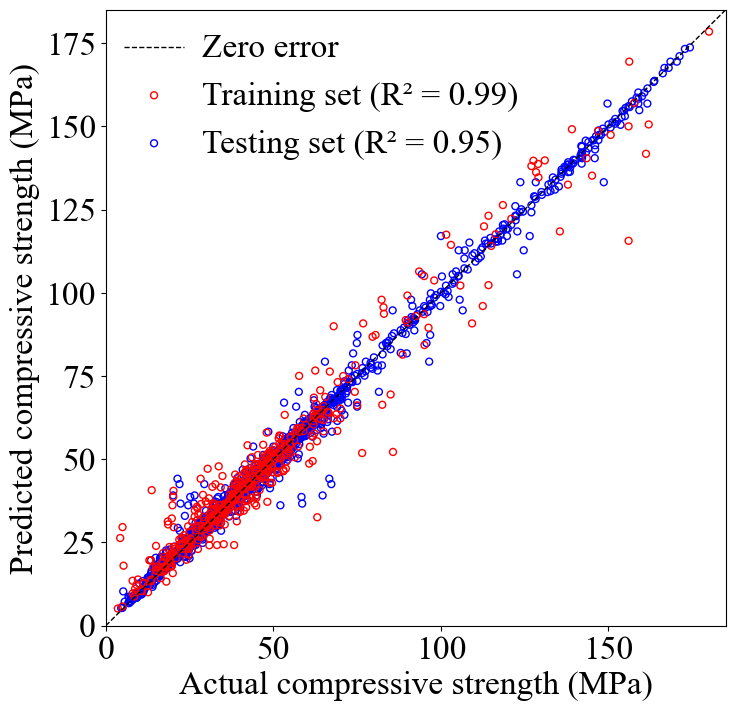

In [2]:
import sys
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from src.data_process import DataHandler
from src.model_train import train_xgboost
from src.plotter import DataPlotter

data_handler = DataHandler(str(DATA_PATH), n_features=16)
data_handler.load_data()

X, y = data_handler.a, data_handler.b
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=172)

result = train_xgboost(x_train, y_train, x_test, y_test)

# plot baseline
y_train_true = result.y_train_true if result.y_train_true is not None else y_train
y_test_true  = result.y_test_true  if result.y_test_true  is not None else y_test

plotter = DataPlotter()
fig, ax = plotter.plot(
    y_train_true, result.y_train_pred,
    y_test_true, result.y_test_pred,
    result.metrics["train"]["r2"], result.metrics["test"]["r2"],
)
fig.savefig(FIG_DIR / "baseline_pred.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


In [3]:
from src.data_augmentation import DataAugmentor

original_df = data_handler.data_df
target_col = original_df.columns[-1]

augmentor = DataAugmentor(baseline_model=result.model)

if TRAIN_CTGAN:
    augmentor.fit_generator(
        full_df=original_df,
        method="CTGAN",
        epochs=3,
        batch_size=500,
        generator_lr=0.0001,
        discriminator_lr=0.0003,
        generator_dim=(512, 1024),
        discriminator_dim=(512, 512),
        verbose=True
    )


D:\BaiduSyncdisk\python3.12.8\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

D:\BaiduSyncdisk\python3.12.8\Lib\site-packages\sdv\single_table\base.py:104: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



开始训练 CTGAN 生成模型（epochs=3）on full data...
生成模型训练完成！总耗时: 0 分 9.39 秒


In [4]:
initial_samples = 150000
n_original = len(original_df)

if REGEN_SYN_POOL:
    syn_data = augmentor.generate_and_predict(
        initial_samples=initial_samples,
        n_original=n_original,
        target_col=target_col
    )


CTGAN 生成 150000 条初始合成数据 (特征 + target)...
应用论文通用后处理 (round, 负值置0)...
警告: 列 'Feature_11' 不存在，跳过 Feature_11 相关约束。请检查列名是否与原始数据匹配。
误差过滤 (error < 0.03 * baseline_pred) 后保留 4649 / 150000 条
负 target 过滤 (Com > 0) 后保留 4649 / 4649 条
最终过滤后剩余 4649 条高质量合成数据 (总通过率: 3.10%)
从过滤池中随机选 2307 条作为 syn_data


原数据量: 2307 条

使用提供的 syn_data (大小: 2307 条)

正在处理 ratio = 0.0 ...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[617]	valid_0's l2: 31.0383	valid_0's l1: 3.50684
Ratio 0.0: RMSE = 5.5712, R² = 0.9668 (合成样本实际添加: 0)

正在处理 ratio = 0.2 ...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[357]	valid_0's l2: 46.1667	valid_0's l1: 4.35415
Ratio 0.2: RMSE = 6.7946, R² = 0.9382 (合成样本实际添加: 461)

正在处理 ratio = 0.4 ...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[369]	valid_0's l2: 51.1793	valid_0's l1: 4.83709
Ratio 0.4: RMSE = 7.1540, R² = 0.9281 (合成样本实际添加: 922)

正在处理 ratio = 0.6 ...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[571]	valid_0's l2: 57.0825	valid_0's l1: 4.95097
Ratio 0.6: RMSE = 7.5553, R² = 0.9182 (合成样本实际添加: 1384)

正在处理 ratio = 0.8 ...
Training until validation scores don't improve fo

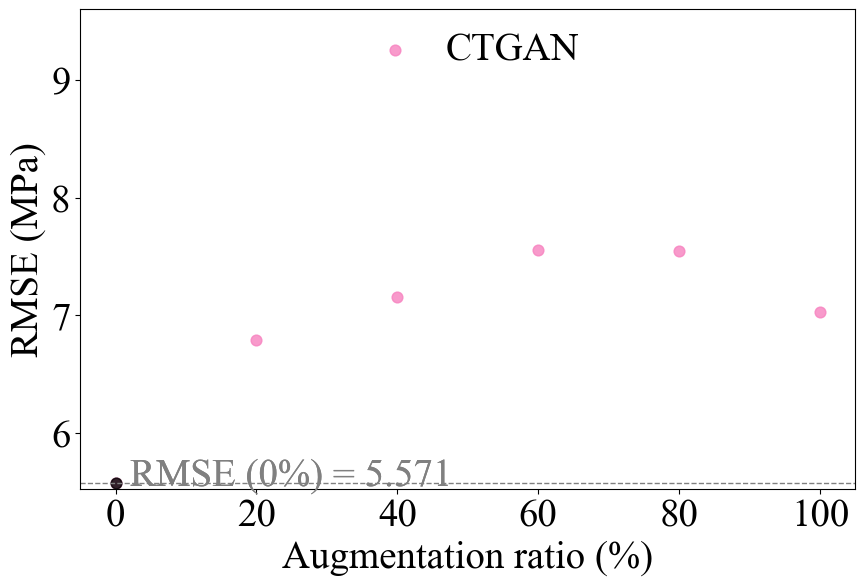

In [5]:
ratios = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

lgb_params_for_aug = {
    "objective": "regression",
    "metric": ["l2", "l1"],   # ✅ 用 list，更稳
    "num_leaves": 69,
    "learning_rate": 0.003 * 62,
    "max_depth": 8,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.91,
    "bagging_fraction": 0.6 + 0.01 * 31,
    "bagging_freq": 2,
    "lambda_l1": 0.11,
    "lambda_l2": 0.14,
    "max_bin": 255 - 20,
    "min_split_gain": 0.0,
    "boosting_type": "gbdt",
    "verbosity": -1,
}

aug_results = augmentor.run_augmentation_experiment(
    original_df=original_df,
    ratios=ratios,
    target_col=target_col,
    lgb_params=lgb_params_for_aug,
    syn_data=syn_data
)

print(aug_results)
aug_results.to_csv(TAB_DIR / "augmentation_experiment.csv", index=False)

fig, ax = plotter.plot_aug_results_rmse(
    aug_results,
    ylabel="RMSE (MPa)",
    save_path=str(FIG_DIR / "augmentation_rmse.png")
)
plt.show()
plt.close(fig)


Computing SHAP values...
SHAP shape: (462, 16)


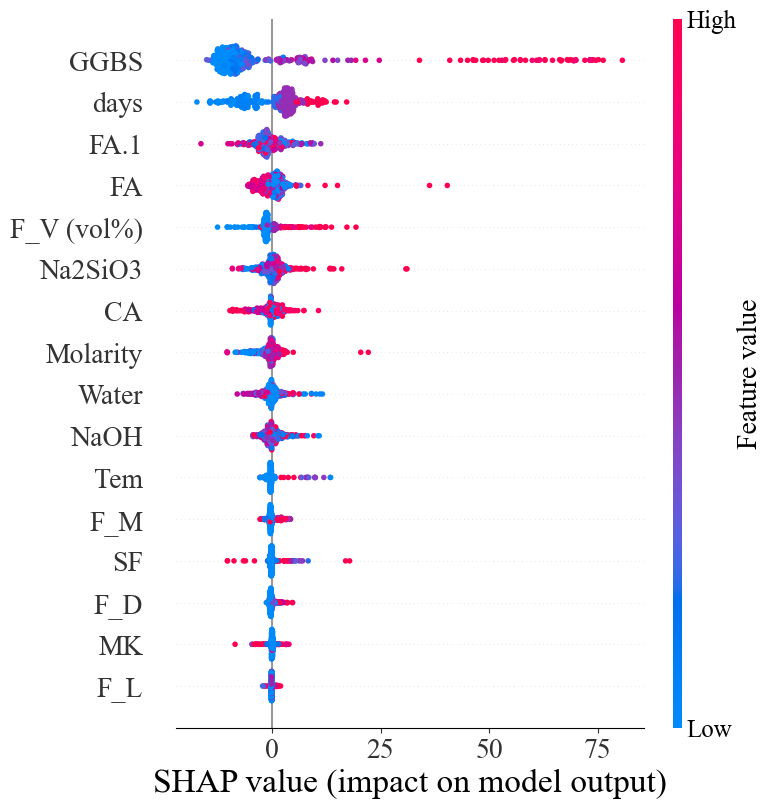

✅ SHAP summary saved.


In [6]:
# ===============================
# 6. SHAP Summary Analysis (Research)
# ===============================

from src.shap import compute_shap_values
from src.plotter import DataPlotter
import pandas as pd
import os

# 如果 x_test 是 ndarray，转成 DataFrame（推荐）
if not isinstance(x_test, pd.DataFrame):
    x_test_df = pd.DataFrame(x_test, columns=data_handler.data_df.columns[:-1])
else:
    x_test_df = x_test

print("Computing SHAP values...")
shap_values = compute_shap_values(result.model, x_test_df)

print("SHAP shape:", shap_values.values.shape)

# 保存路径
os.makedirs(r"..\results\figures", exist_ok=True)

plotter = DataPlotter()
fig, ax = plotter.plot_shap_summary(
    shap_values,
    x_test_df,
    save_path=r"..\results\figures\shap_summary.png"
)

plt.show()
plt.close(fig)

print("✅ SHAP summary saved.")


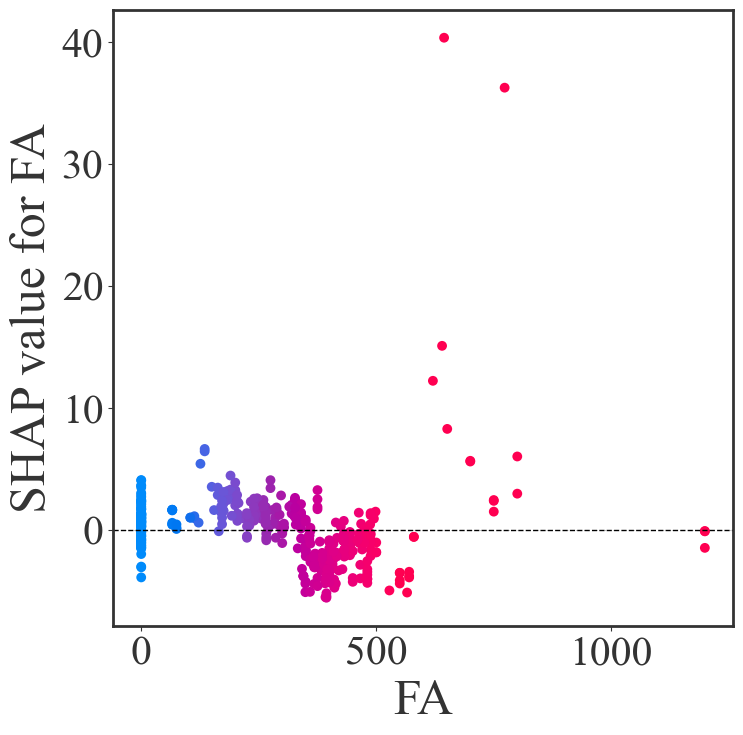

✅ Saved single SHAP scatter plot.


In [8]:
# ===============================
# 7. SHAP Scatter Plot (Single Feature)
# ===============================

import os
import matplotlib.pyplot as plt
from src.plotter import DataPlotter

required_vars = ["shap_values", "x_test_df"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"缺少变量 {missing}，请先运行第 6 步 SHAP summary cell。")

save_dir = r"..\results\figures\shap_scatter"
os.makedirs(save_dir, exist_ok=True)

plotter = DataPlotter()

feature_names = list(x_test_df.columns)

fig, ax = plotter.plot_shap_scatter_one(
    shap_values=shap_values,
    x_data=x_test_df,
    feature=0,                     # 第一个特征
    feature_names=feature_names,
    point_size=50,
    save_path=os.path.join(save_dir, "shap_scatter_0.png")
)

plt.show()
plt.close(fig)

print("✅ Saved single SHAP scatter plot.")
